# SOEC hydrogen NPV simulation

Run the Monte Carlo hydrogen model at 100,000 tH2/year. The notebook shows NPV, LPM, and LCOH distributions, NPV sign counts, and mean annual cost components. Greenfield European solid-oxide electrolysis for 2030, with electric process heat.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from hydrogen.hydrogen_npv_monte_carlo import (
    DEFAULT_RANDOM_SEED,
    DEFAULT_RETROFIT_BAU_MODE,
    DEFAULT_SAMPLE_SIZE,
    simulate_hydrogen_results,
)
from npv_summary import summarize_metric_signs
from npv_summary_plots import plot_financial_metric_distribution

pd.options.display.float_format = "{:,.3f}".format

In [2]:
TECHNOLOGY = "soec"
SAMPLE_SIZE = DEFAULT_SAMPLE_SIZE
RANDOM_SEED = DEFAULT_RANDOM_SEED
RETROFIT_BAU_MODE = DEFAULT_RETROFIT_BAU_MODE

simulation = simulate_hydrogen_results(
    sample_size=SAMPLE_SIZE,
    random_seed=RANDOM_SEED,
    technologies=(TECHNOLOGY,),
    retrofit_bau_mode=RETROFIT_BAU_MODE,
)[TECHNOLOGY]
results = pd.DataFrame(simulation)
results.head()

,run_id,technology,technology_type,retrofit_bau_mode,annual_output_th2,lifetime_years,capex_eur_per_th2,fixed_opex_eur_per_th2,variable_opex_eur_per_th2,fuel_type,...,annual_electricity_cost_eur,annual_transport_and_storage_cost_eur,annual_emissions_cost_eur,annual_total_cost_eur,annual_net_cash_flow_eur,npv_eur,discounted_lifetime_output_th2,present_value_total_cost_eur,lcoh_eur_per_th2,levelized_profit_margin_eur_per_th2
0,0,soec,absolute,not_applicable,"100,000.000",25,"5,221.407",213.121,80.338,none,...,"554,531,384.149",0.000,0.000,"583,877,239.071","166,122,760.929","1,251,182,637.610","1,067,477.619","6,754,899,503.832","6,327.907","1,172.093"
1,1,soec,absolute,not_applicable,"100,000.000",25,"6,320.587",260.956,80.119,none,...,"616,397,192.345",0.000,0.000,"650,504,713.284","99,495,286.716","430,031,234.353","1,067,477.619","7,576,050,907.089","7,097.152",402.848
2,2,soec,absolute,not_applicable,"100,000.000",25,"5,086.905",209.650,80.413,none,...,"514,804,104.032",0.000,0.000,"543,810,442.916","206,189,557.084","1,692,336,881.386","1,067,477.619","6,313,745,260.056","5,914.639","1,585.361"
3,3,soec,absolute,not_applicable,"100,000.000",25,"6,385.705",310.516,83.001,none,...,"651,419,662.983",0.000,0.000,"690,771,347.090","59,228,652.910","-6,317,875.237","1,067,477.619","8,012,400,016.678","7,505.919",-5.919
4,4,soec,absolute,not_applicable,"100,000.000",25,"4,288.995",238.312,83.123,none,...,"326,722,389.938",0.000,0.000,"358,865,882.975","391,134,117.025","3,746,369,655.624","1,067,477.619","4,259,712,485.818","3,990.447","3,509.553"


In [3]:
npv_million_eur = results["npv_eur"] / 1_000_000
lcoh_eur_per_th2 = results["lcoh_eur_per_th2"]
levelized_profit_margin_eur_per_th2 = results["levelized_profit_margin_eur_per_th2"]

summary = pd.concat([
    npv_million_eur.describe(percentiles=[0.05, 0.5, 0.95]).rename("NPV million EUR"),
    levelized_profit_margin_eur_per_th2.describe(percentiles=[0.05, 0.5, 0.95]).rename("LPM EUR/tH2"),
    lcoh_eur_per_th2.describe(percentiles=[0.05, 0.5, 0.95]).rename("LCOH EUR/tH2"),
], axis=1)
npv_signs = summarize_metric_signs(npv_million_eur)
npv_sign_summary = pd.DataFrame([
    {"NPV category": "Non-negative (NPV >= 0)", "Count": npv_signs["non_negative_count"], "Share": npv_signs["non_negative_share"]},
    {"NPV category": "Negative (NPV < 0)", "Count": npv_signs["negative_count"], "Share": 1 - npv_signs["non_negative_share"]},
])
display(summary, npv_sign_summary)

,NPV million EUR,LPM EUR/tH2,LCOH EUR/tH2
count,"100,000.000","100,000.000","100,000.000"
mean,"1,787.285","1,674.307","5,825.693"
std,"1,115.165","1,044.673","1,044.673"
min,-879.094,-823.525,"3,356.604"
5%,-37.109,-34.764,"4,119.567"
50%,"1,784.709","1,671.894","5,828.106"
95%,"3,608.537","3,380.433","7,534.764"
max,"4,422.982","4,143.396","8,323.525"


,NPV category,Count,Share
0,Non-negative (NPV >= 0),94476,0.945
1,Negative (NPV < 0),5524,0.055


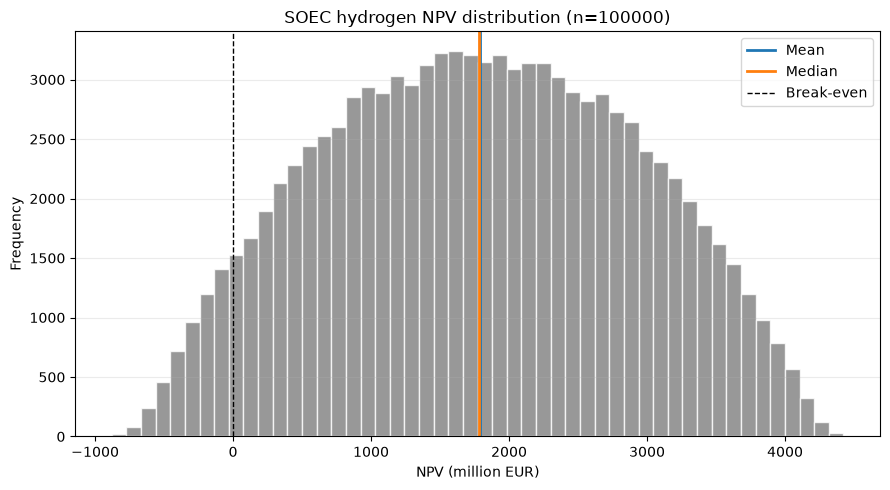

In [4]:
plot_financial_metric_distribution(
    npv_million_eur,
    title=f"SOEC hydrogen NPV distribution (n={SAMPLE_SIZE})",
    x_axis_label="NPV (million EUR)",
    color="tab:gray",
    show_break_even=True,
)
plt.show()

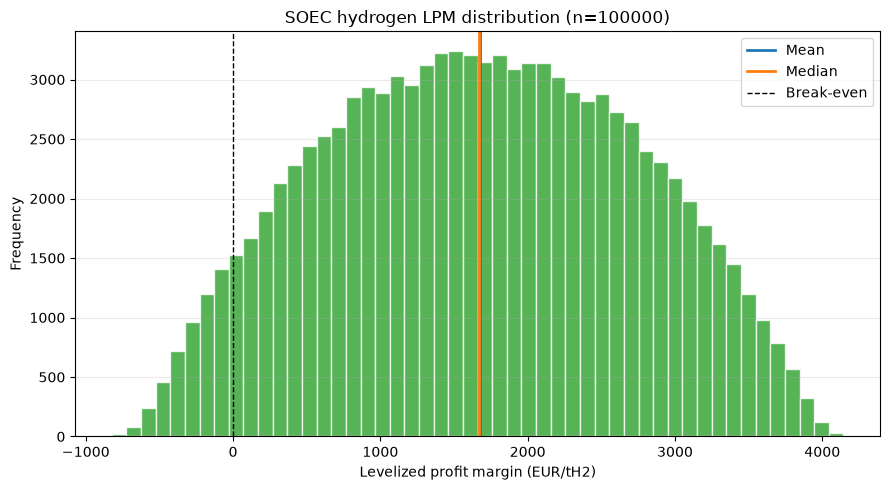

In [5]:
plot_financial_metric_distribution(
    levelized_profit_margin_eur_per_th2,
    title=f"SOEC hydrogen LPM distribution (n={SAMPLE_SIZE})",
    x_axis_label="Levelized profit margin (EUR/tH2)",
    color="tab:green",
    show_break_even=True,
)
plt.show()

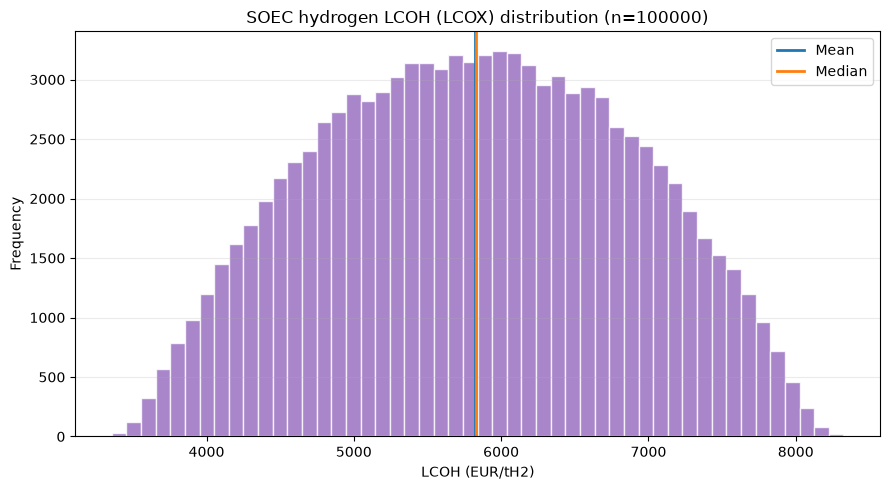

In [6]:
plot_financial_metric_distribution(
    lcoh_eur_per_th2,
    title=f"SOEC hydrogen LCOH (LCOX) distribution (n={SAMPLE_SIZE})",
    x_axis_label="LCOH (EUR/tH2)",
    color="tab:purple",
)
plt.show()

In [7]:
annual_columns = [
    "annual_revenue_eur",
    "annual_fixed_opex_eur",
    "annual_variable_opex_eur",
    "annual_natural_gas_cost_eur",
    "annual_biomethane_cost_eur",
    "annual_biomass_cost_eur",
    "annual_fuel_cost_eur",
    "annual_electricity_cost_eur",
    "annual_transport_and_storage_cost_eur",
    "annual_emissions_cost_eur",
    "annual_net_cash_flow_eur",
]
(results[annual_columns] / 1_000_000).mean().rename("Mean annual value, million EUR")

annual_revenue_eur                      750.000
annual_fixed_opex_eur                    27.519
annual_variable_opex_eur                  8.167
annual_natural_gas_cost_eur               0.000
annual_biomethane_cost_eur                0.000
annual_biomass_cost_eur                   0.000
annual_fuel_cost_eur                      0.000
annual_electricity_cost_eur             492.008
annual_transport_and_storage_cost_eur     0.000
annual_emissions_cost_eur                 0.000
annual_net_cash_flow_eur                222.306
Name: Mean annual value, million EUR, dtype: float64